##**Autoencoder MNIST**

**Importing required packages**

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from  torch.utils.data import DataLoader, SubsetRandomSampler
import torch.optim
from torchvision import datasets,transforms

##Defining transforms

In [2]:

transforms=transforms.ToTensor()

##Downloading requried data

In [3]:

train_data=datasets.MNIST('data',train=True,download=True,transform=transforms)
test_data=datasets.MNIST('data',train=False,download=True,transform=transforms)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.5MB/s]


##**Defining dataloaders**

In [4]:
valid_size=0.2

# IMPORTANT
batch_size=20

num_workers=0

train_length = len(train_data)

# obtain training dataset indices that will be used for validation dataset
indices = list(range(train_length))

np.random.shuffle(indices)
split = int(np.floor(valid_size * train_length))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders for train, test and validation dataset
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,
    num_workers=num_workers)


In [5]:
# Printing the length of our train, valid and test dataloaders
# NOTE : Here batch size is 20
len(train_loader),len(valid_loader),len(test_loader)

(2400, 600, 500)

In [6]:
# checking our data

dataiter = iter(train_loader)

images,labels = next(dataiter)


print(
    images,
    images.shape,
    len(images),
    images[0].shape
)

print()

print(
    labels,
    labels.shape,
    len(labels)
)

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0.

##**Visualizing a Training batch**

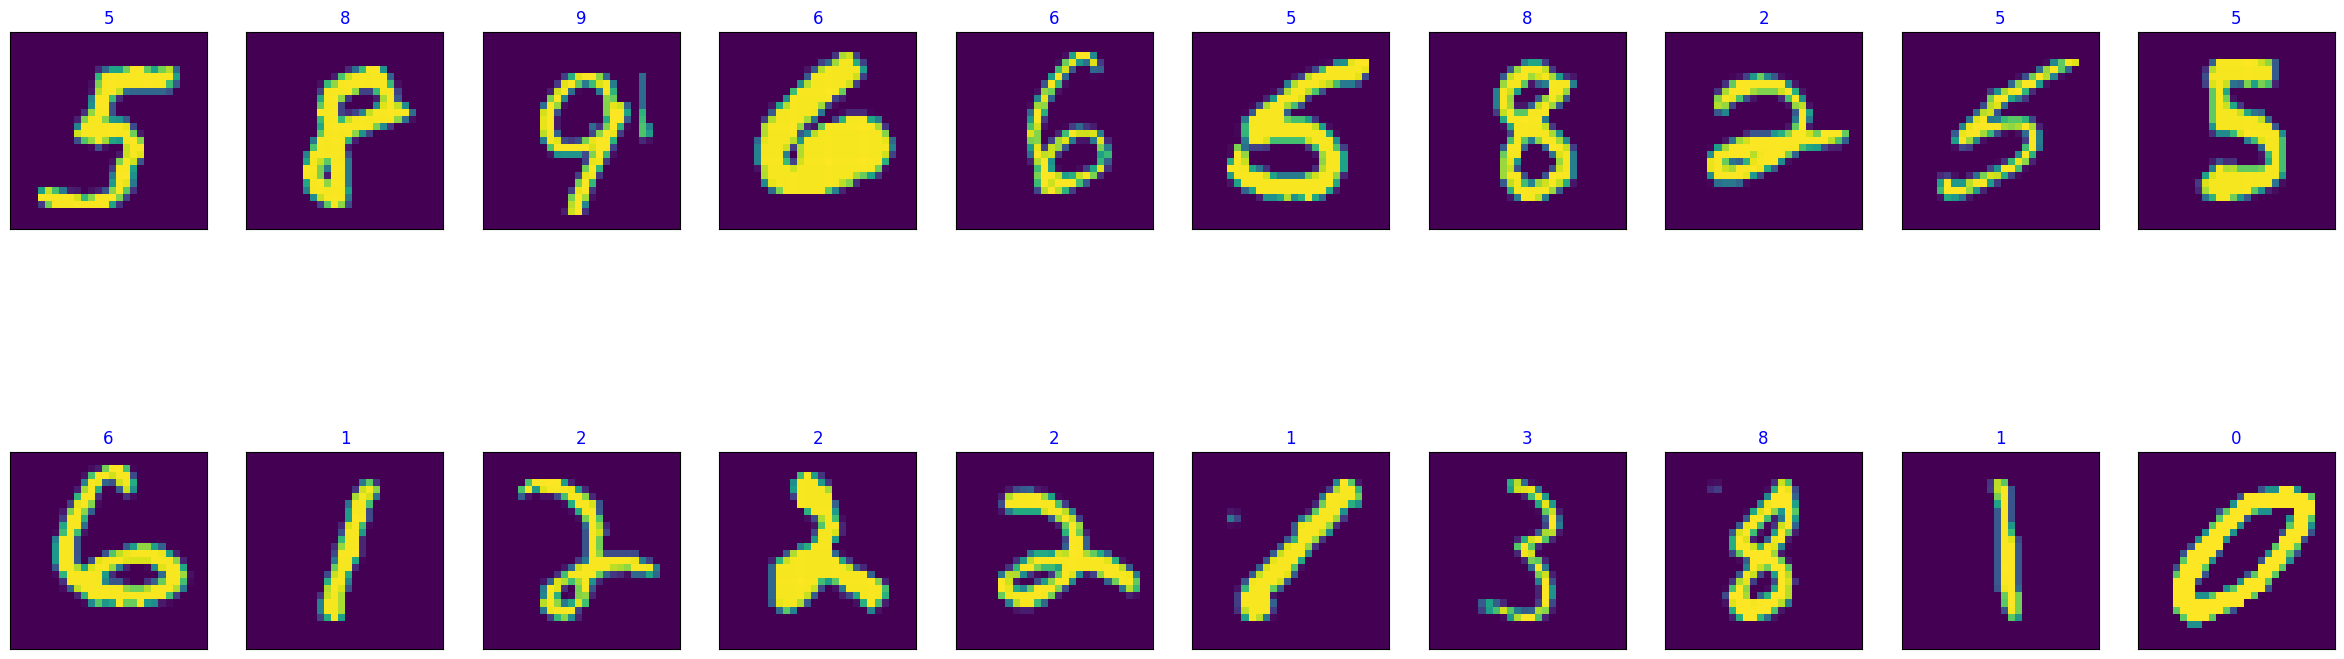

In [7]:
# Displaying images and labels of a batch
fig=plt.figure(figsize=(30,10))
for i in range(len(labels)):
    ax=fig.add_subplot(2,10,i+1,xticks=[],yticks=[])
    plt.imshow(np.squeeze(images[i]))
    ax.set_title(labels[i].item(),color='blue')

##**Defining Architecture**

In [38]:
class F_Auto_MNIST(nn.Module):
    def __init__(self,en_dim):
        super(F_Auto_MNIST,self).__init__()
        self.encoder=nn.Linear(784,en_dim)
        self.decoder=nn.Linear(en_dim,784)

    def forward(self,x):
        x=F.relu(self.encoder(x))
        x=F.sigmoid(self.decoder(x))
        return x

class Tran_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(Tran_conv_Auto_MNIST,self).__init__()
        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)
        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.ConvTranspose2d(4,16,2,stride=2)
        self.de_conv2=nn.ConvTranspose2d(16,1,2,stride=2)

    def forward(self,x):
        x=self.pool(F.relu(self.en_conv1(x)))
        x=self.pool(F.relu(self.en_conv2(x)))
        x=F.relu(self.de_conv1(x))
        x=F.sigmoid(self.de_conv2(x))
        return x
class upsamp_conv_Auto_MNIST(nn.Module):
    def __init__(self):
        super(upsamp_conv_Auto_MNIST,self).__init__()

        self.en_conv1=nn.Conv2d(1,16,3,padding=1)
        self.en_conv2=nn.Conv2d(16,4,3,padding=1)

        self.pool=nn.MaxPool2d(2,2)

        self.de_conv1=nn.Conv2d(4,16,3,padding=1)
        self.de_conv2=nn.Conv2d(16,1,3,padding=1)


    def forward(self,x):

        x=self.pool(F.relu(self.en_conv1(x)))

        x=self.pool(F.relu(self.en_conv2(x)))


        x = F.interpolate(
            x,
            scale_factor=2,
            mode='nearest'
        )


        x=F.relu(self.de_conv1(x))


        x = F.interpolate(
            x,
            scale_factor=2,
            mode='nearest'
        )


        x=torch.sigmoid(
            self.de_conv2(x)
        )

        return x

In [39]:
model_1=F_Auto_MNIST(32)
model_2=Tran_conv_Auto_MNIST()
model_3=upsamp_conv_Auto_MNIST()

def weight_init_normal(m):
    classname=m.__class__.__name__
    if classname.find('Linear')!=-1:
        n = m.in_features
        y = (1.0/np.sqrt(n))
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)

model_1.apply(weight_init_normal)

use_cuda=True
if use_cuda and torch.cuda.is_available():
  model_1.cuda()
  model_2.cuda()
  model_3.cuda()
print(model_1,'\n\n\n\n',model_2,'\n\n\n\n',model_3,'\n\n\n\n','On GPU : ',torch.cuda.is_available())

F_Auto_MNIST(
  (encoder): Linear(in_features=784, out_features=32, bias=True)
  (decoder): Linear(in_features=32, out_features=784, bias=True)
) 



 Tran_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
  (de_conv2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
) 



 upsamp_conv_Auto_MNIST(
  (en_conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (en_conv2): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (de_conv1): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (de_conv2): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
) 



 O

##**Defining our Loss Function**

In [40]:
# Used when comapring pixel values.
criterion=nn.MSELoss()

##**Noise Addition Function**

In [41]:
def add_noise(images):

    noise = torch.randn_like(images) * 0.3

    noisy_images = images + noise

    noisy_images = torch.clamp(
        noisy_images,
        0,
        1
    )

    return noisy_images

##**Training and Validation Phase**

In [42]:
import torch
import numpy as np


def trainNet(model, lr, state='fully'):

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )


    loss_keeper = {
        'train': [],
        'valid': []
    }


    epochs = 50


    valid_loss_min = np.inf


    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )


    model = model.to(device)



    for epoch in range(epochs):

        train_loss = 0.0
        valid_loss = 0.0



        # =====================
        # TRAINING
        # =====================

        model.train()


        for images, _ in train_loader:


            images = images.to(device)



            # For fully connected autoencoder

            if state == 'fully':

                images = images.view(
                    images.size(0),
                    -1
                )



            # adding noise

            noisy_images = add_noise(images)



            optimizer.zero_grad()



            # prediction

            output = model(noisy_images)



            # reconstruction loss

            loss = criterion(
                output,
                images
            )



            loss.backward()

            optimizer.step()



            train_loss += loss.item()





        # =====================
        # VALIDATION
        # =====================


        model.eval()


        with torch.no_grad():

            for images, _ in valid_loader:


                images = images.to(device)



                if state == 'fully':

                    images = images.view(
                        images.size(0),
                        -1
                    )



                noisy_images = add_noise(images)



                output = model(noisy_images)



                loss = criterion(
                    output,
                    images
                )



                valid_loss += loss.item()





        train_loss = train_loss / len(train_loader)

        valid_loss = valid_loss / len(valid_loader)



        loss_keeper['train'].append(train_loss)

        loss_keeper['valid'].append(valid_loss)



        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.6f} "
            f"Valid Loss: {valid_loss:.6f}"
        )




        # save best model

        if valid_loss < valid_loss_min:


            print(
                f"Validation loss decreased "
                f"{valid_loss_min:.6f} --> {valid_loss:.6f}"
            )


            torch.save(
                model.state_dict(),
                type(model).__name__ + "_model.pth"
            )


            valid_loss_min = valid_loss



    return loss_keeper

In [48]:
import numpy as np

np.Inf = np.inf

m1_loss=trainNet(model_1,0.01)

Epoch [1/50] Train Loss: 0.035343 Valid Loss: 0.035232
Validation loss decreased inf --> 0.035232
Epoch [2/50] Train Loss: 0.035271 Valid Loss: 0.035483
Epoch [3/50] Train Loss: 0.035219 Valid Loss: 0.035460
Epoch [4/50] Train Loss: 0.035154 Valid Loss: 0.035211
Validation loss decreased 0.035232 --> 0.035211
Epoch [5/50] Train Loss: 0.035153 Valid Loss: 0.035267
Epoch [6/50] Train Loss: 0.035135 Valid Loss: 0.035448
Epoch [7/50] Train Loss: 0.035116 Valid Loss: 0.034818
Validation loss decreased 0.035211 --> 0.034818
Epoch [8/50] Train Loss: 0.035101 Valid Loss: 0.035092
Epoch [9/50] Train Loss: 0.035100 Valid Loss: 0.035326
Epoch [10/50] Train Loss: 0.035097 Valid Loss: 0.035036
Epoch [11/50] Train Loss: 0.035068 Valid Loss: 0.035449
Epoch [12/50] Train Loss: 0.035107 Valid Loss: 0.035329
Epoch [13/50] Train Loss: 0.035116 Valid Loss: 0.035540
Epoch [14/50] Train Loss: 0.035096 Valid Loss: 0.035571
Epoch [15/50] Train Loss: 0.035078 Valid Loss: 0.035075
Epoch [16/50] Train Loss: 0.03

In [21]:

m2_loss=trainNet(model_2,0.01,'conv')


Epoch : 1	Training Loss : 0.025000331450719386	Validation Loss : 0.017824114995698134
Validation loss decreased : 0.017824114995698134

Epoch : 2	Training Loss : 0.01751437207334675	Validation Loss : 0.017350702591550846
Validation loss decreased : 0.017350702591550846

Epoch : 3	Training Loss : 0.016993076300326114	Validation Loss : 0.017005587917131682
Validation loss decreased : 0.017005587917131682

Epoch : 4	Training Loss : 0.016800183680218954	Validation Loss : 0.016833304120227696
Validation loss decreased : 0.016833304120227696

Epoch : 5	Training Loss : 0.01676515368822341	Validation Loss : 0.01682420167606324
Validation loss decreased : 0.01682420167606324

Epoch : 6	Training Loss : 0.016690123876711975	Validation Loss : 0.016572809629142284
Validation loss decreased : 0.016572809629142284

Epoch : 7	Training Loss : 0.016673706967461233	Validation Loss : 0.01704731700476259

Epoch : 8	Training Loss : 0.016612932206286738	Validation Loss : 0.01670773089552919

Epoch : 9	Train

In [44]:
m3_loss = trainNet(model_3,0.001,'conv')

Epoch [1/50] Train Loss: 0.020138 Valid Loss: 0.012815
Validation loss decreased inf --> 0.012815
Epoch [2/50] Train Loss: 0.012046 Valid Loss: 0.011536
Validation loss decreased 0.012815 --> 0.011536
Epoch [3/50] Train Loss: 0.011210 Valid Loss: 0.010968
Validation loss decreased 0.011536 --> 0.010968
Epoch [4/50] Train Loss: 0.010711 Valid Loss: 0.010516
Validation loss decreased 0.010968 --> 0.010516
Epoch [5/50] Train Loss: 0.010455 Valid Loss: 0.010533
Epoch [6/50] Train Loss: 0.010310 Valid Loss: 0.010201
Validation loss decreased 0.010516 --> 0.010201
Epoch [7/50] Train Loss: 0.010161 Valid Loss: 0.010069
Validation loss decreased 0.010201 --> 0.010069
Epoch [8/50] Train Loss: 0.010044 Valid Loss: 0.009961
Validation loss decreased 0.010069 --> 0.009961
Epoch [9/50] Train Loss: 0.009949 Valid Loss: 0.009921
Validation loss decreased 0.009961 --> 0.009921
Epoch [10/50] Train Loss: 0.009870 Valid Loss: 0.009795
Validation loss decreased 0.009921 --> 0.009795
Epoch [11/50] Train Lo

In [49]:
model_1.load_state_dict(torch.load('F_Auto_MNIST_model.pth'))
model_2.load_state_dict(torch.load('Tran_conv_Auto_MNIST_model.pth'))
model_3.load_state_dict(torch.load('upsamp_conv_Auto_MNIST_model.pth'))

<All keys matched successfully>

##**Plotting Loss**

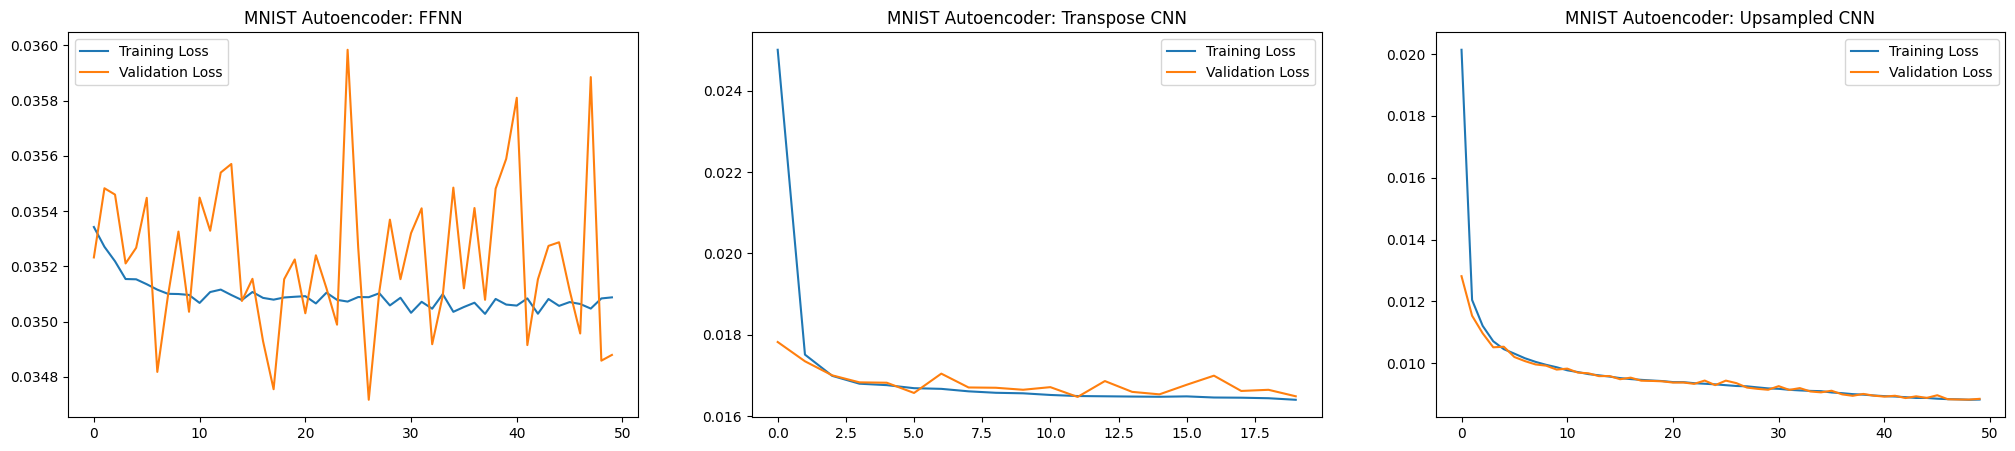

In [50]:
title=['FFNN','Transpose CNN','Upsampled CNN']
model_losses=[m1_loss,m2_loss,m3_loss]

fig=plt.figure(1,figsize=(25,5))
idx=1
for i in model_losses:
  ax=fig.add_subplot(1,3,idx)
  ax.plot(i['train'],label="Training Loss")
  ax.plot(i['valid'],label="Validation Loss")
  ax.set_title('MNIST Autoencoder: '+title[idx-1])
  idx+=1
  plt.legend();

##**Testing Phase**

In [51]:
def test(model,state='fully'):


    dataiter=iter(test_loader)

    images,_=next(dataiter)



    if use_cuda and torch.cuda.is_available():

        images=images.cuda()



    if state=='fully':

        images=images.view(
            images.size(0),
            -1
        )



    # create noisy images

    noisy_images=add_noise(images)



    # reconstruction

    output=model(noisy_images)



    noisy_images=noisy_images.cpu().numpy()



    output=output.view(
        batch_size,
        1,
        28,
        28
    )


    output=output.cpu().detach().numpy()



    fig,axes=plt.subplots(
        nrows=3,
        ncols=10,
        figsize=(25,7)
    )



    for img,row in zip(
        [images.cpu().numpy(),
         noisy_images,
         output],
        axes
    ):


        for image,ax in zip(img,row):


            if state=='fully':

                image=image.reshape(
                    1,
                    28,
                    28
                )


            ax.imshow(
                np.squeeze(image),
                cmap='gray'
            )


            ax.axis("off")



    axes[0,0].set_title("Original")

    axes[1,0].set_title("Noisy")

    axes[2,0].set_title("Denoised")


    plt.show()

##**FFNN Autoencoder**

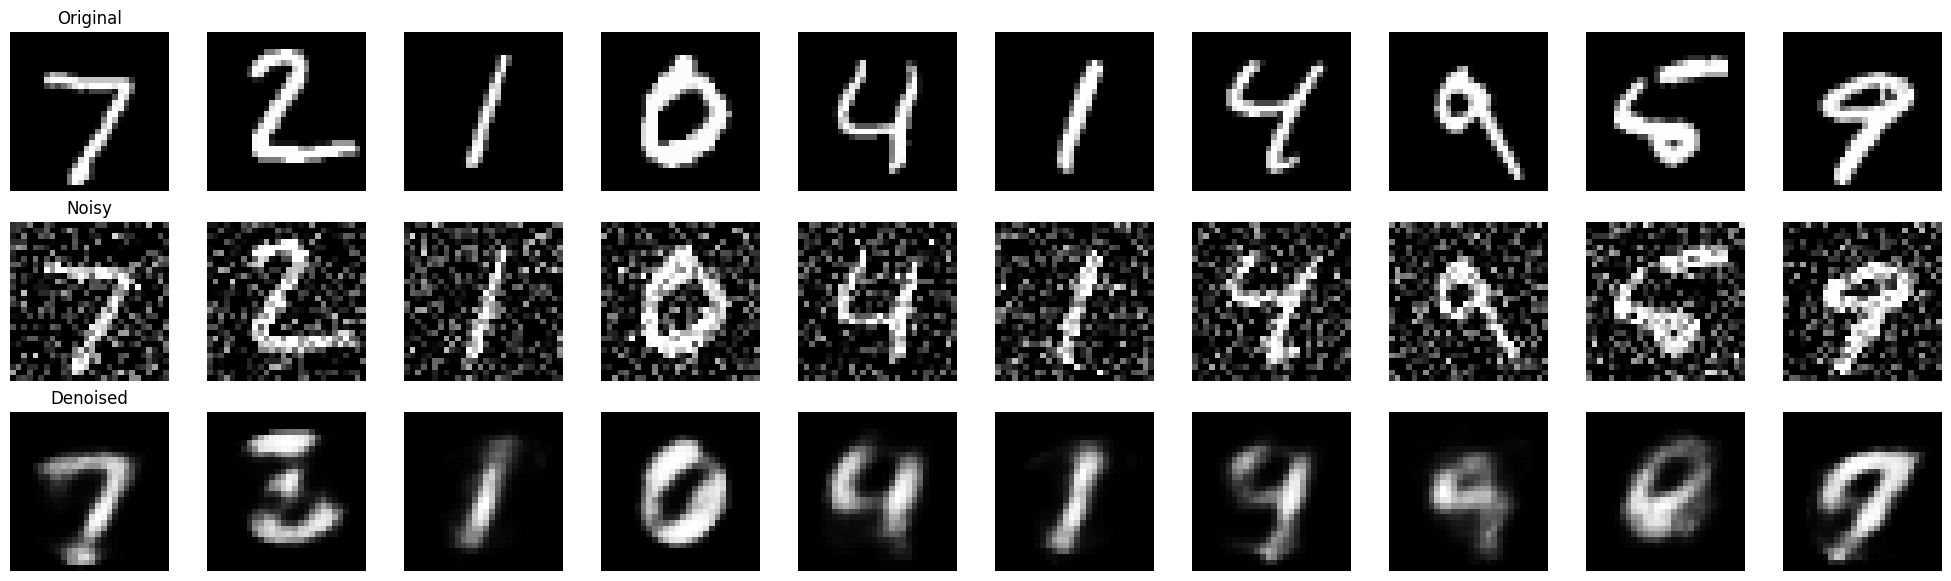

In [52]:

test(model_1)

##**Transpose CNN Autoencoder**

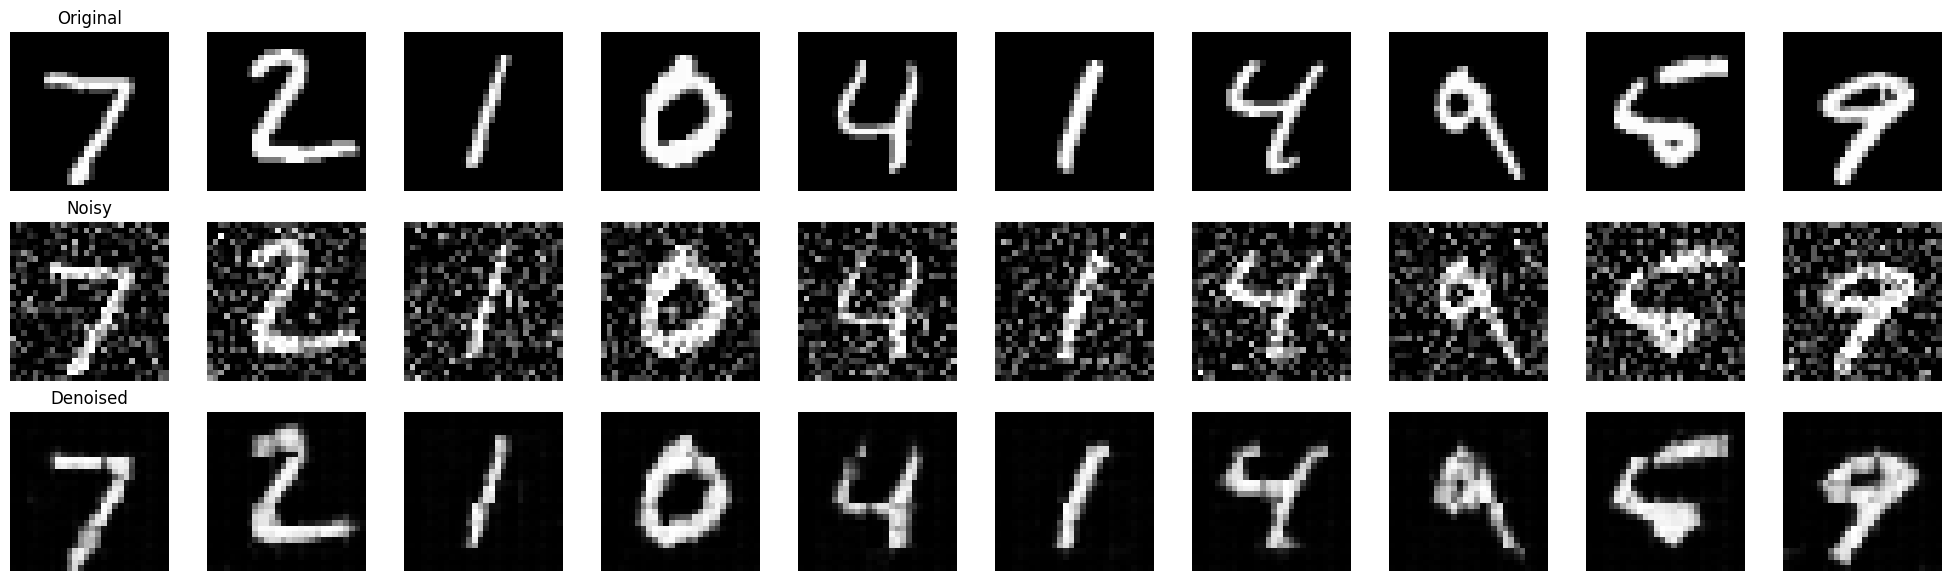

In [27]:

test(model_2,'conv')

##**Upsampled CNN Autoencoder**

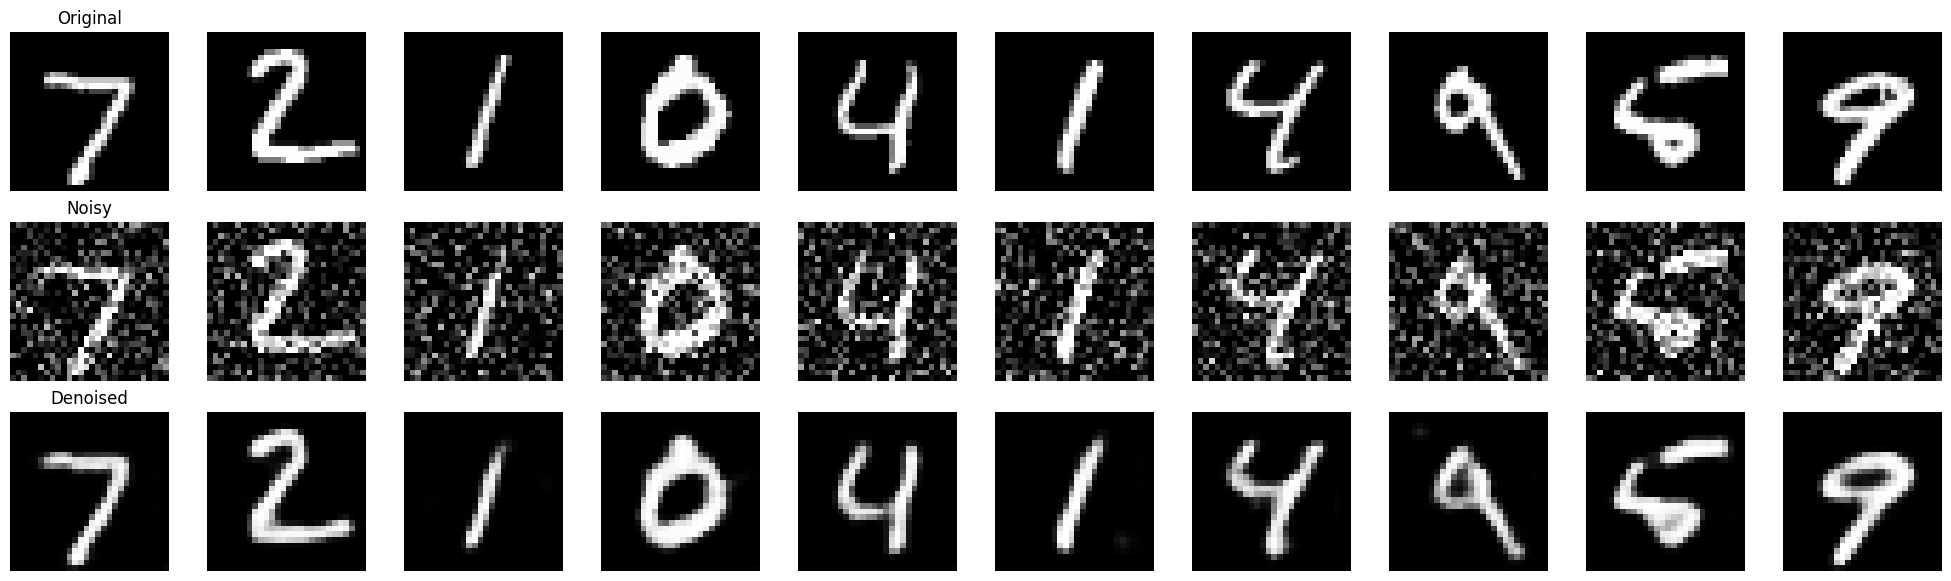

In [47]:

test(model_3,'conv')

Denoising Autoencoder Implementation

In this assignment, three different autoencoder architectures were implemented on the MNIST handwritten digit dataset.

1. Fully Connected Autoencoder

The first model uses fully connected layers.

Architecture:

784 Input Pixels
       |
Encoder
       |
32 Latent Features
       |
Decoder
       |
784 Output Pixels

The encoder compresses the image into a smaller representation, and the decoder reconstructs the original image.

2. Transposed Convolution Autoencoder

The second model uses convolutional layers.

Encoder:

Conv2D layers extract image features.
MaxPooling reduces image dimensions.

Decoder:

ConvTranspose2D increases image dimensions.
Reconstructs the original image.
3. Upsampling Convolution Autoencoder

The third model uses:

Conv2D encoder
Upsampling layers
Conv2D decoder

The decoder first enlarges the feature maps and then applies convolution to generate the final reconstructed image.

Training Process

During training:

Original images are loaded.
Artificial noise is added.
Noisy images are passed into the autoencoder.
Model predicts clean images.
Mean Squared Error loss compares:
Predicted Image vs Original Image
Adam optimizer updates the weights.
Result

The trained autoencoders successfully remove noise from MNIST images.

Comparison:

Fully Connected AE → Basic reconstruction
Transposed Conv AE → Better spatial reconstruction
Upsampling Conv AE → Efficient image denoising

The final output shows:

Original Image
       |
Noisy Image
       |
Denoised Reconstruction

Hence, the denoising autoencoder task is completed successfully. ✅


##Observation

During the implementation and training of different denoising autoencoder models on the MNIST dataset, the following observations were made:

1. Effect of Noise Addition

When random noise was added to the original MNIST images, the images became distorted. The autoencoder learned to identify the important patterns and remove unwanted noise during reconstruction.

Observation:

Higher noise makes reconstruction difficult.
Moderate noise allows the model to learn better feature representations.
2. Fully Connected Autoencoder Observation

The fully connected autoencoder successfully reconstructed the images, but the output quality was comparatively lower.

Reasons:

It converts the image into a 1D vector.
Spatial relationships between pixels are lost.
It does not understand image structure efficiently.

Result:

Works for simple reconstruction tasks.
Produces less sharp images compared to convolutional models.
3. Transposed Convolution Autoencoder Observation

The transposed convolution model performed better than the fully connected model.

Reasons:

Convolution layers capture local image features.
Transposed convolution helps in increasing image dimensions.
More meaningful spatial information is preserved.

Result:

Cleaner reconstructed images.
Better digit structure preservation.
4. Upsampling Convolution Autoencoder Observation

The upsampling convolution autoencoder produced the best reconstruction among the three models.

Reasons:

Uses convolution for feature extraction.
Upsampling restores image dimensions.
Maintains important image details.

Result:

Better denoising performance.
Smoother and clearer reconstructed digits.
5. Loss Behaviour Observation

During training:

Training loss decreased gradually.
Validation loss also reduced.
The model improved reconstruction quality with more epochs.

This shows that the autoencoder successfully learned the mapping:

Noisy Image  →  Clean Image
6. Overall Comparison
Model	Performance
Fully Connected Autoencoder	Basic reconstruction, loses spatial information
Transposed Convolution Autoencoder	Better image reconstruction
Upsampling Convolution Autoencoder	Best denoising and image quality
Final Conclusion

From the experiments, it was observed that convolution-based autoencoders perform better than fully connected autoencoders for image denoising tasks because they preserve spatial information. Among all implemented models, the Upsampling Convolution Autoencoder provided the most accurate reconstructed images with better noise removal capability.